<a href="https://colab.research.google.com/github/nuoxi3007/data-analysis-projects/blob/main/02-pc-market-analysis/analyze-eda-model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Разведочный и статистический анализ


## Проект по стажировке Цифровой кафедры "Аналитика данных" (Уровень ADVANCED)

Данный блокнот охватывает этапы **Разведочного анализа данных (EDA)**, **Моделирования** и **Оценки**, а также формулировку **Рекомендаций для Заказчика (Внедрение)**.


## Импорт необходимых библиотек и загрузка данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import (
    shapiro, ttest_ind, mannwhitneyu, kruskal,
    chi2_contingency, pearsonr, spearmanr
)
import warnings
warnings.filterwarnings('ignore')

from google.colab import files
uploaded = files.upload()

In [ ]:
df = pd.read_csv('data_clear.csv')
df.head()

,product_id,price,sales,feedbacks,seller,seller_rating,GPU,Operating_System,CPU_Type,CPU_Cores,RAM_Type,RAM_Size_GB,HDD_Size,SSD_Size,package_length_cm,package_width_cm,package_height_cm,package_weight_kg
0,10148385,10805.0,200,7,Other,4.7,Intel,No_OS,Intel Celeron,2,DDR,4,0,0,43.5,12.5,34.0,5.0
1,17877962,32900.0,0,0,Other,4.7,Other,No_OS,Intel Core i5,6,Other,16,0,256,43.0,25.0,50.0,8.0
2,17880420,35720.0,0,0,Other,4.7,Other,No_OS,не заполнено,2,Other,16,0,512,46.0,25.0,50.0,8.0
3,19347937,39237.0,10,1,Robotcomp,4.7,Intel,Windows,Intel Core i5,6,DDR,8,0,480,60.0,30.0,60.0,8.0
4,19348951,76188.0,200,94,Robotcomp,4.7,Nvidia,Windows,Intel Core i5,6,DDR,16,0,960,50.0,24.0,50.0,8.0


## Общий анализ

###Общая информация

In [ ]:
# Общая информация о данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3968 entries, 0 to 3967
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   product_id         3968 non-null   int64  
 1   price              3968 non-null   float64
 2   sales              3968 non-null   int64  
 3   feedbacks          3968 non-null   int64  
 4   seller             3968 non-null   object 
 5   seller_rating      3968 non-null   float64
 6   GPU                3968 non-null   object 
 7   Operating_System   3968 non-null   object 
 8   CPU_Type           3968 non-null   object 
 9   CPU_Cores          3968 non-null   int64  
 10  RAM_Type           3968 non-null   object 
 11  RAM_Size_GB        3968 non-null   int64  
 12  HDD_Size           3968 non-null   int64  
 13  SSD_Size           3968 non-null   int64  
 14  package_length_cm  3968 non-null   float64
 15  package_width_cm   3968 non-null   float64
 16  package_height_cm  3968 

###Анализ числовых признаков

In [ ]:
# Выбор числовых признаков
numeric_df = df.select_dtypes(include=['int64', 'float64']).drop(columns=['product_id'], errors='ignore')

# Основная статистика
desc = numeric_df.describe().T
desc['median'] = numeric_df.median()
desc['skew'] = numeric_df.skew()
desc['kurtosis'] = numeric_df.kurtosis()
desc

,count,mean,std,min,25%,50%,75%,max,median,skew,kurtosis
price,3968.0,62644.305444,34382.304648,132.00,36125.0,63627.0,82000.0,200000.0,63627.0,0.695702,0.924481
sales,3968.0,4.264113,18.982507,0.00,0.0,0.0,5.0,200.0,0.0,8.087246,73.647871
feedbacks,3968.0,2.306452,11.438389,0.00,0.0,0.0,0.0,100.0,0.0,6.956149,50.719288
seller_rating,3968.0,4.311190,0.641373,3.00,4.1,4.7,4.7,5.0,4.7,-1.249335,0.123891
CPU_Cores,3968.0,6.081401,3.708251,1.00,4.0,6.0,6.0,24.0,6.0,2.119118,7.055266
RAM_Size_GB,3968.0,17.086442,10.178955,1.00,8.0,16.0,16.0,64.0,16.0,1.933504,5.694599
HDD_Size,3968.0,243.490675,421.023307,0.00,0.0,0.0,500.0,1024.0,0.0,1.196948,-0.512916
SSD_Size,3968.0,475.396673,327.846460,0.00,240.0,480.0,512.0,1024.0,480.0,0.370786,-0.881030
package_length_cm,3968.0,45.102649,14.149604,0.40,39.0,47.0,60.0,95.0,47.0,-0.759279,-0.047941
package_width_cm,3968.0,27.958828,10.631048,0.21,24.0,25.0,30.0,60.0,25.0,1.063431,2.272679


In [ ]:
# Тест Шапиро-Уилка на нормальность
for col in numeric_df.columns:
    data = numeric_df[col].dropna()
    stat, p = shapiro(data)
    print(f"{col}: p-value = {p:.4f}")


price: p-value = 0.0000
sales: p-value = 0.0000
feedbacks: p-value = 0.0000
seller_rating: p-value = 0.0000
CPU_Cores: p-value = 0.0000
RAM_Size_GB: p-value = 0.0000
HDD_Size: p-value = 0.0000
SSD_Size: p-value = 0.0000
package_length_cm: p-value = 0.0000
package_width_cm: p-value = 0.0000
package_height_cm: p-value = 0.0000
package_weight_kg: p-value = 0.0000


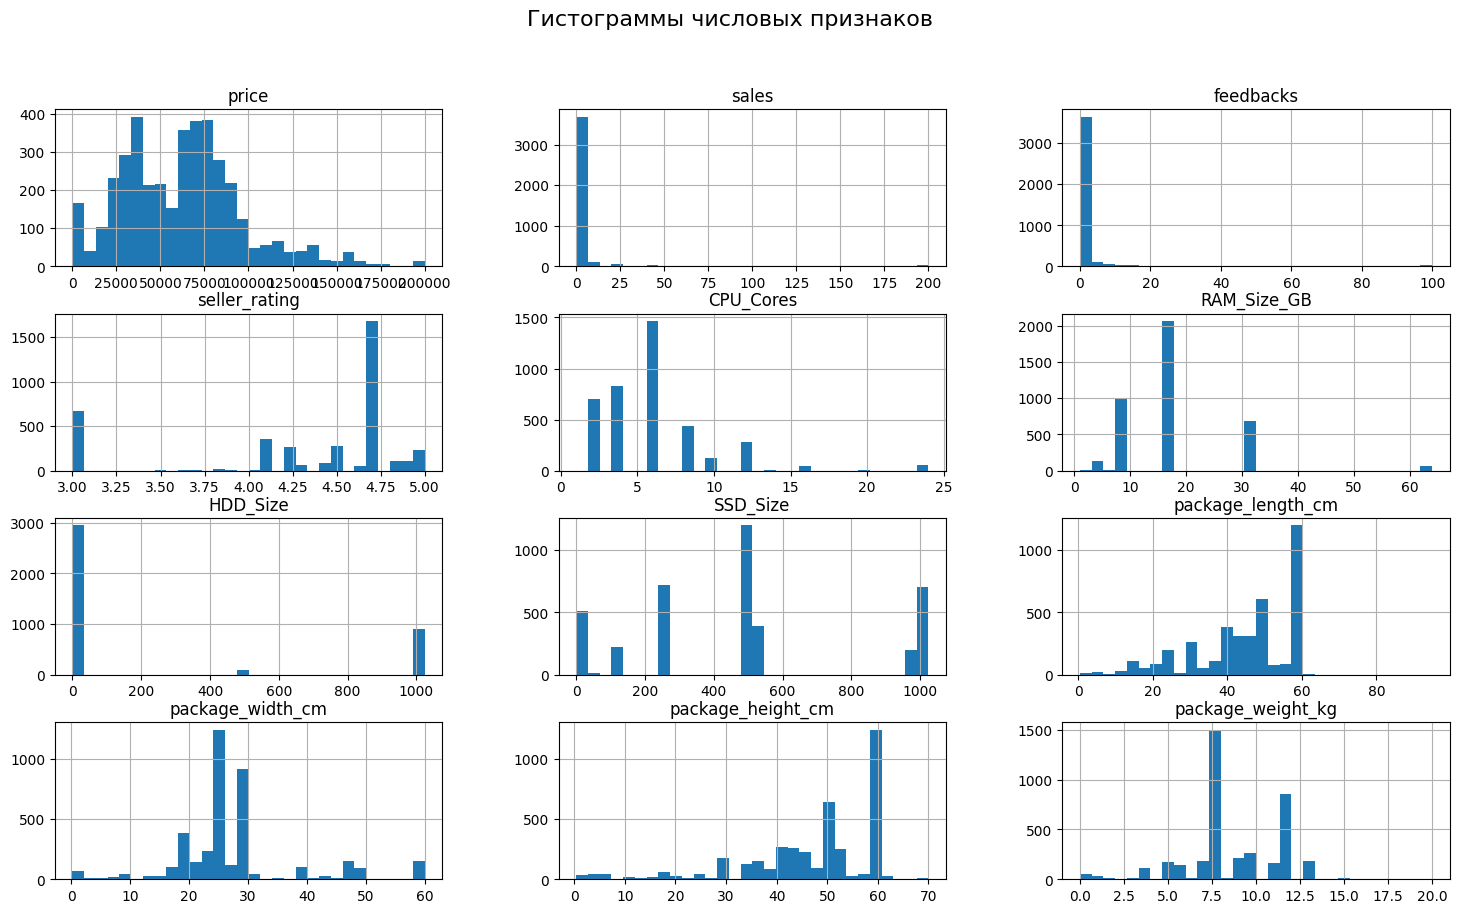

In [ ]:
# Гистограммы
numeric_df.hist(bins=30, figsize=(18, 10))
plt.suptitle("Гистограммы числовых признаков", fontsize=16)
plt.show()

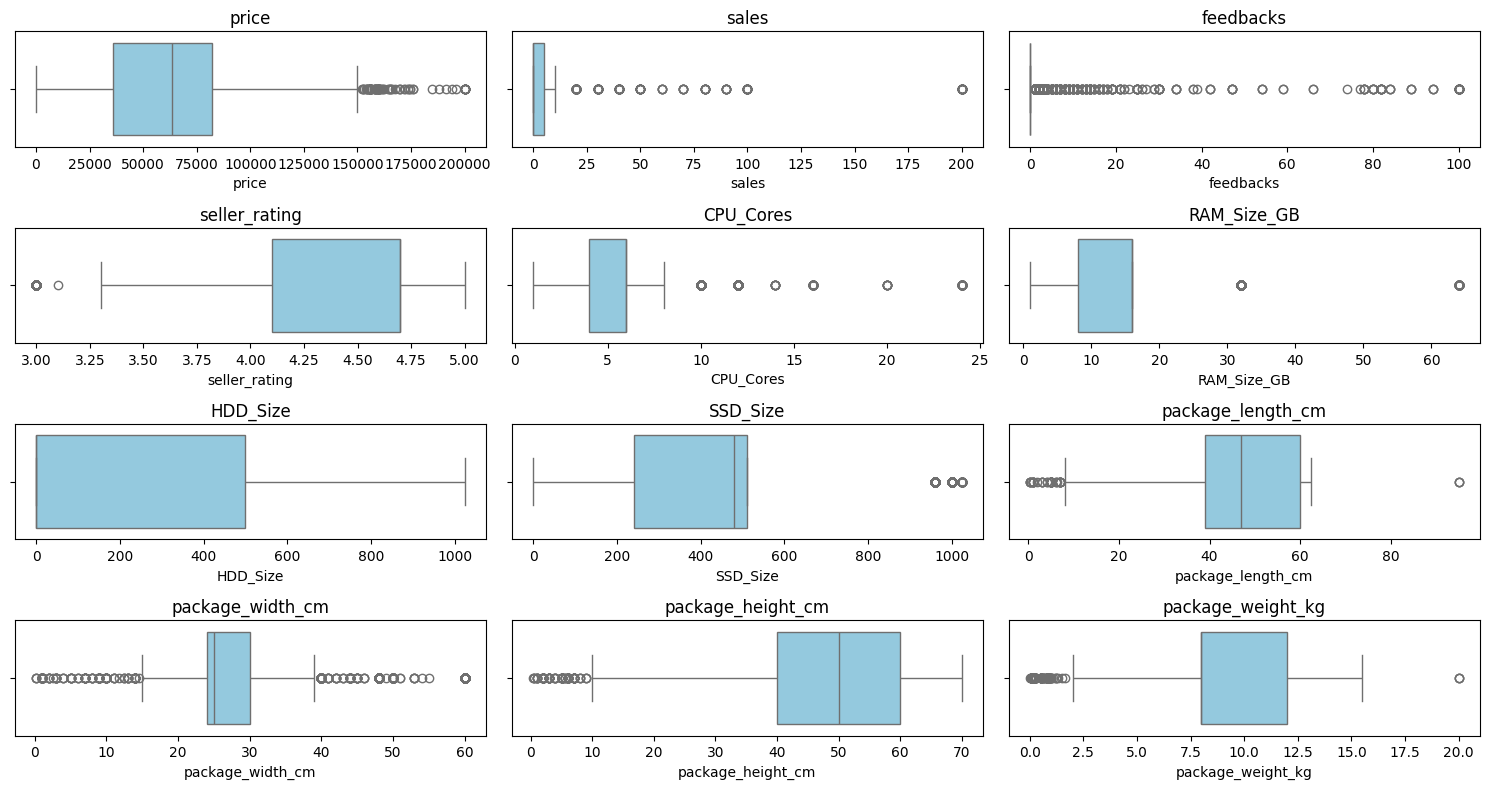

In [ ]:
# Boxplot
cols = 3
rows = (numeric_df.shape[1] + cols - 1) // cols

plt.figure(figsize=(cols * 5, rows * 2))

for i, col in enumerate(numeric_df.columns, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=numeric_df[col], color='skyblue')
    plt.title(col)
    plt.tight_layout()

plt.show()

#### Вывод:
### Итог анализа данных

Мы изучили распределение числовых признаков по показателям асимметрии и "жирности" хвостов.

- Некоторые показатели, например, `sales`, `feedbacks`, `CPU_Cores` и `RAM_Size_GB`, сильно смещены вправо и имеют большое количество выбросов. Такие данные лучше преобразовать, например, с помощью логарифма или разбивки на группы, чтобы улучшить качество анализа.
- Признаки `SSD_Size` и `package_weight_kg` имеют почти симметричное распределение и могут использоваться без изменений.
- Многие другие признаки не соответствуют нормальному распределению, поэтому для анализа и моделирования лучше использовать методы, которые не требуют нормальности (например, деревья решений или ансамбли).
- Важно учитывать это при дальнейшем выборе моделей и обработке данных, чтобы избежать ошибок и неправильных выводов.

Таким образом, данные имеют неоднородное распределение, и к ним нужен индивидуальный подход для обработки.


###Анализ категориальных признаков

In [ ]:
cat_df = df.select_dtypes(include=['object', 'bool'])

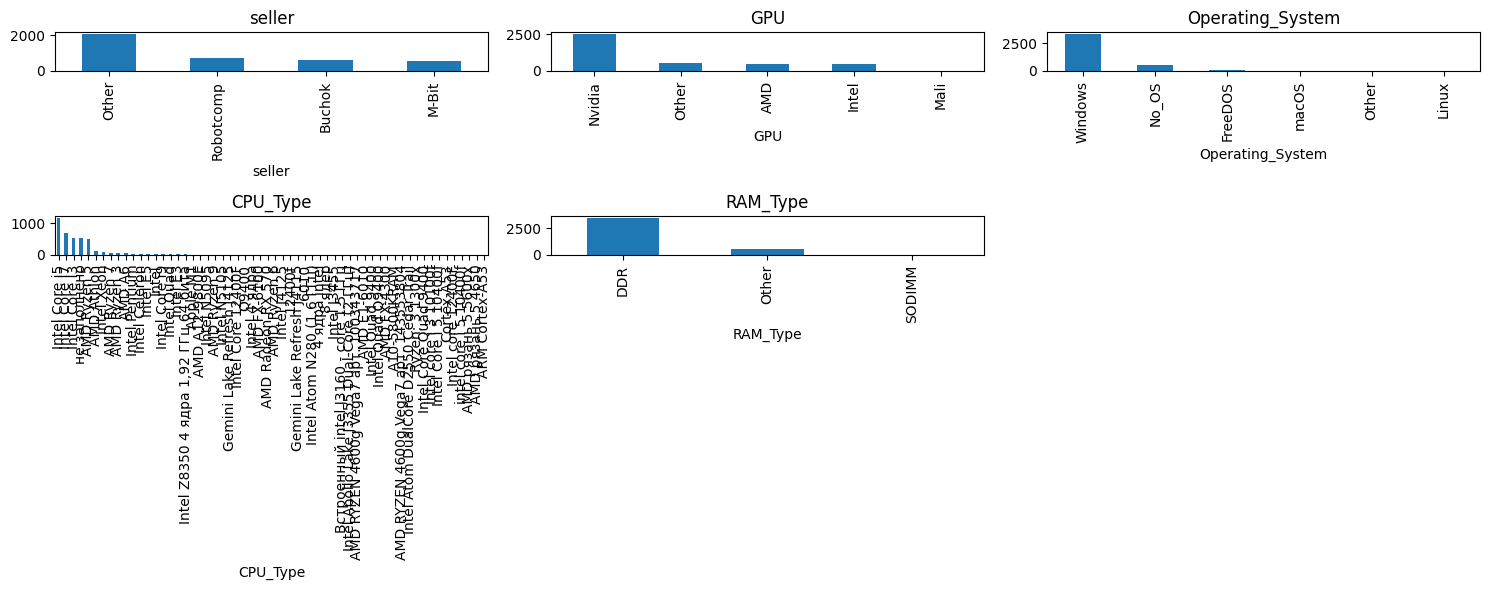

In [ ]:
# Частоты и графики
cols = 3
rows = (cat_df.shape[1] + cols - 1) // cols

plt.figure(figsize=(cols * 5, rows * 3))

for i, col in enumerate(cat_df.columns, 1):
    plt.subplot(rows, cols, i)
    cat_df[col].value_counts().plot(kind='bar', title=col)
    plt.title(col)
    plt.tight_layout()

plt.show()

### Вывод по категориальным признакам

Категориальные признаки в данных представлены разным количеством уникальных значений, обычно не более 6. В некоторых случаях одна категория сильно преобладает над остальными, что говорит о дисбалансе данных. Это важно учитывать, так как дисбаланс может негативно влиять на качество моделей и их способность правильно прогнозировать редкие категории.

Например, если большинство товаров имеют один и тот же тип операционной системы или производителя, модель может плохо распознавать менее популярные варианты. Поэтому при построении моделей стоит применять методы работы с несбалансированными данными, такие как взвешивание классов или дополнительная генерация данных.

Кроме того, категориальные признаки удобно использовать для визуализации и сравнения групп товаров, что помогает выявить закономерности в популярности и ценах на рынке.

В целом, данные категориальные признаки достаточно информативны и помогут в дальнейшем анализе и прогнозировании.


## Анализ взаимосвязей

###Анализ взаимосвязей числовых признаков

In [ ]:
def draw_corr_heatmap(df):
  df_num = (
      df.copy()
      .select_dtypes(include=['int64', 'float64'])
      .drop(columns=['product_id'], errors='ignore')
  )
  plt.figure(figsize=(12, 10))
  sns.heatmap(df_num.corr(), annot=True, fmt=".2f", cmap="coolwarm")
  plt.title("Корреляции между числовыми признаками")
  plt.show()


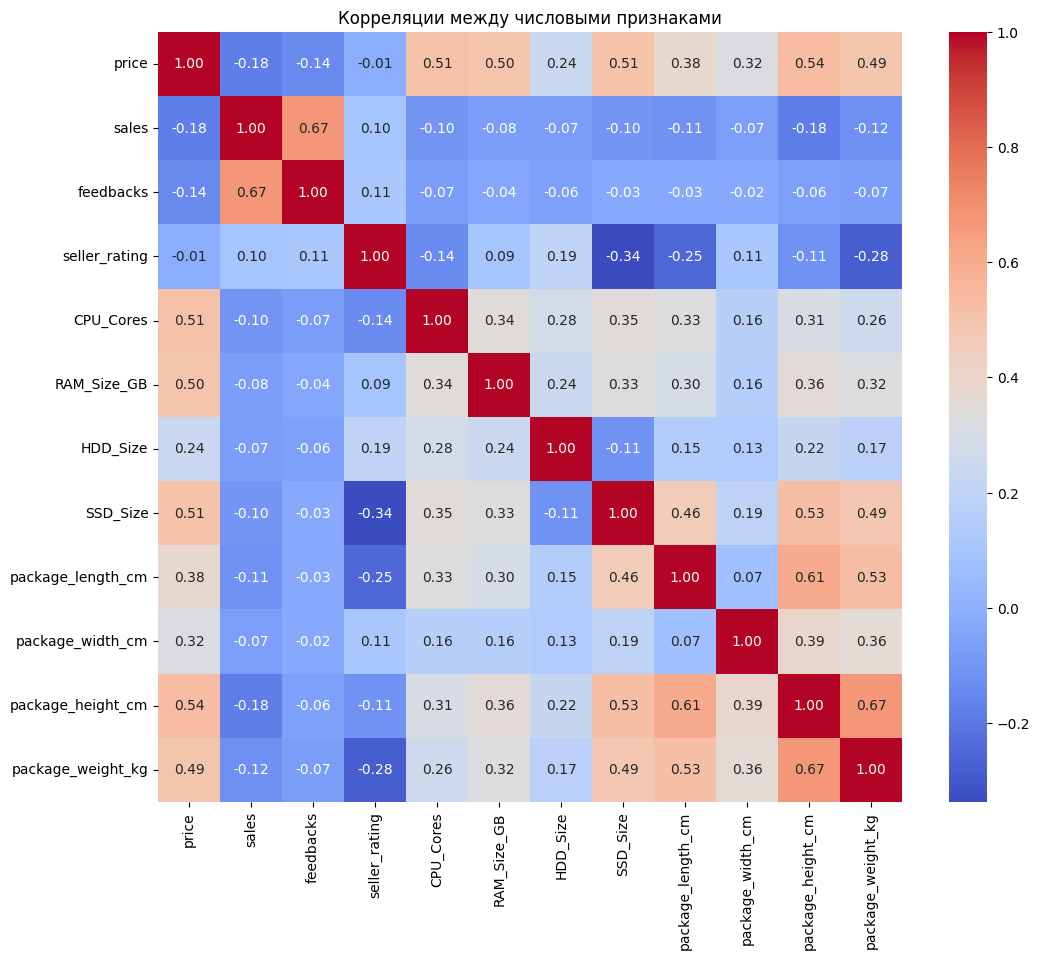

In [ ]:
# Корреляционная матрица
draw_corr_heatmap(numeric_df)

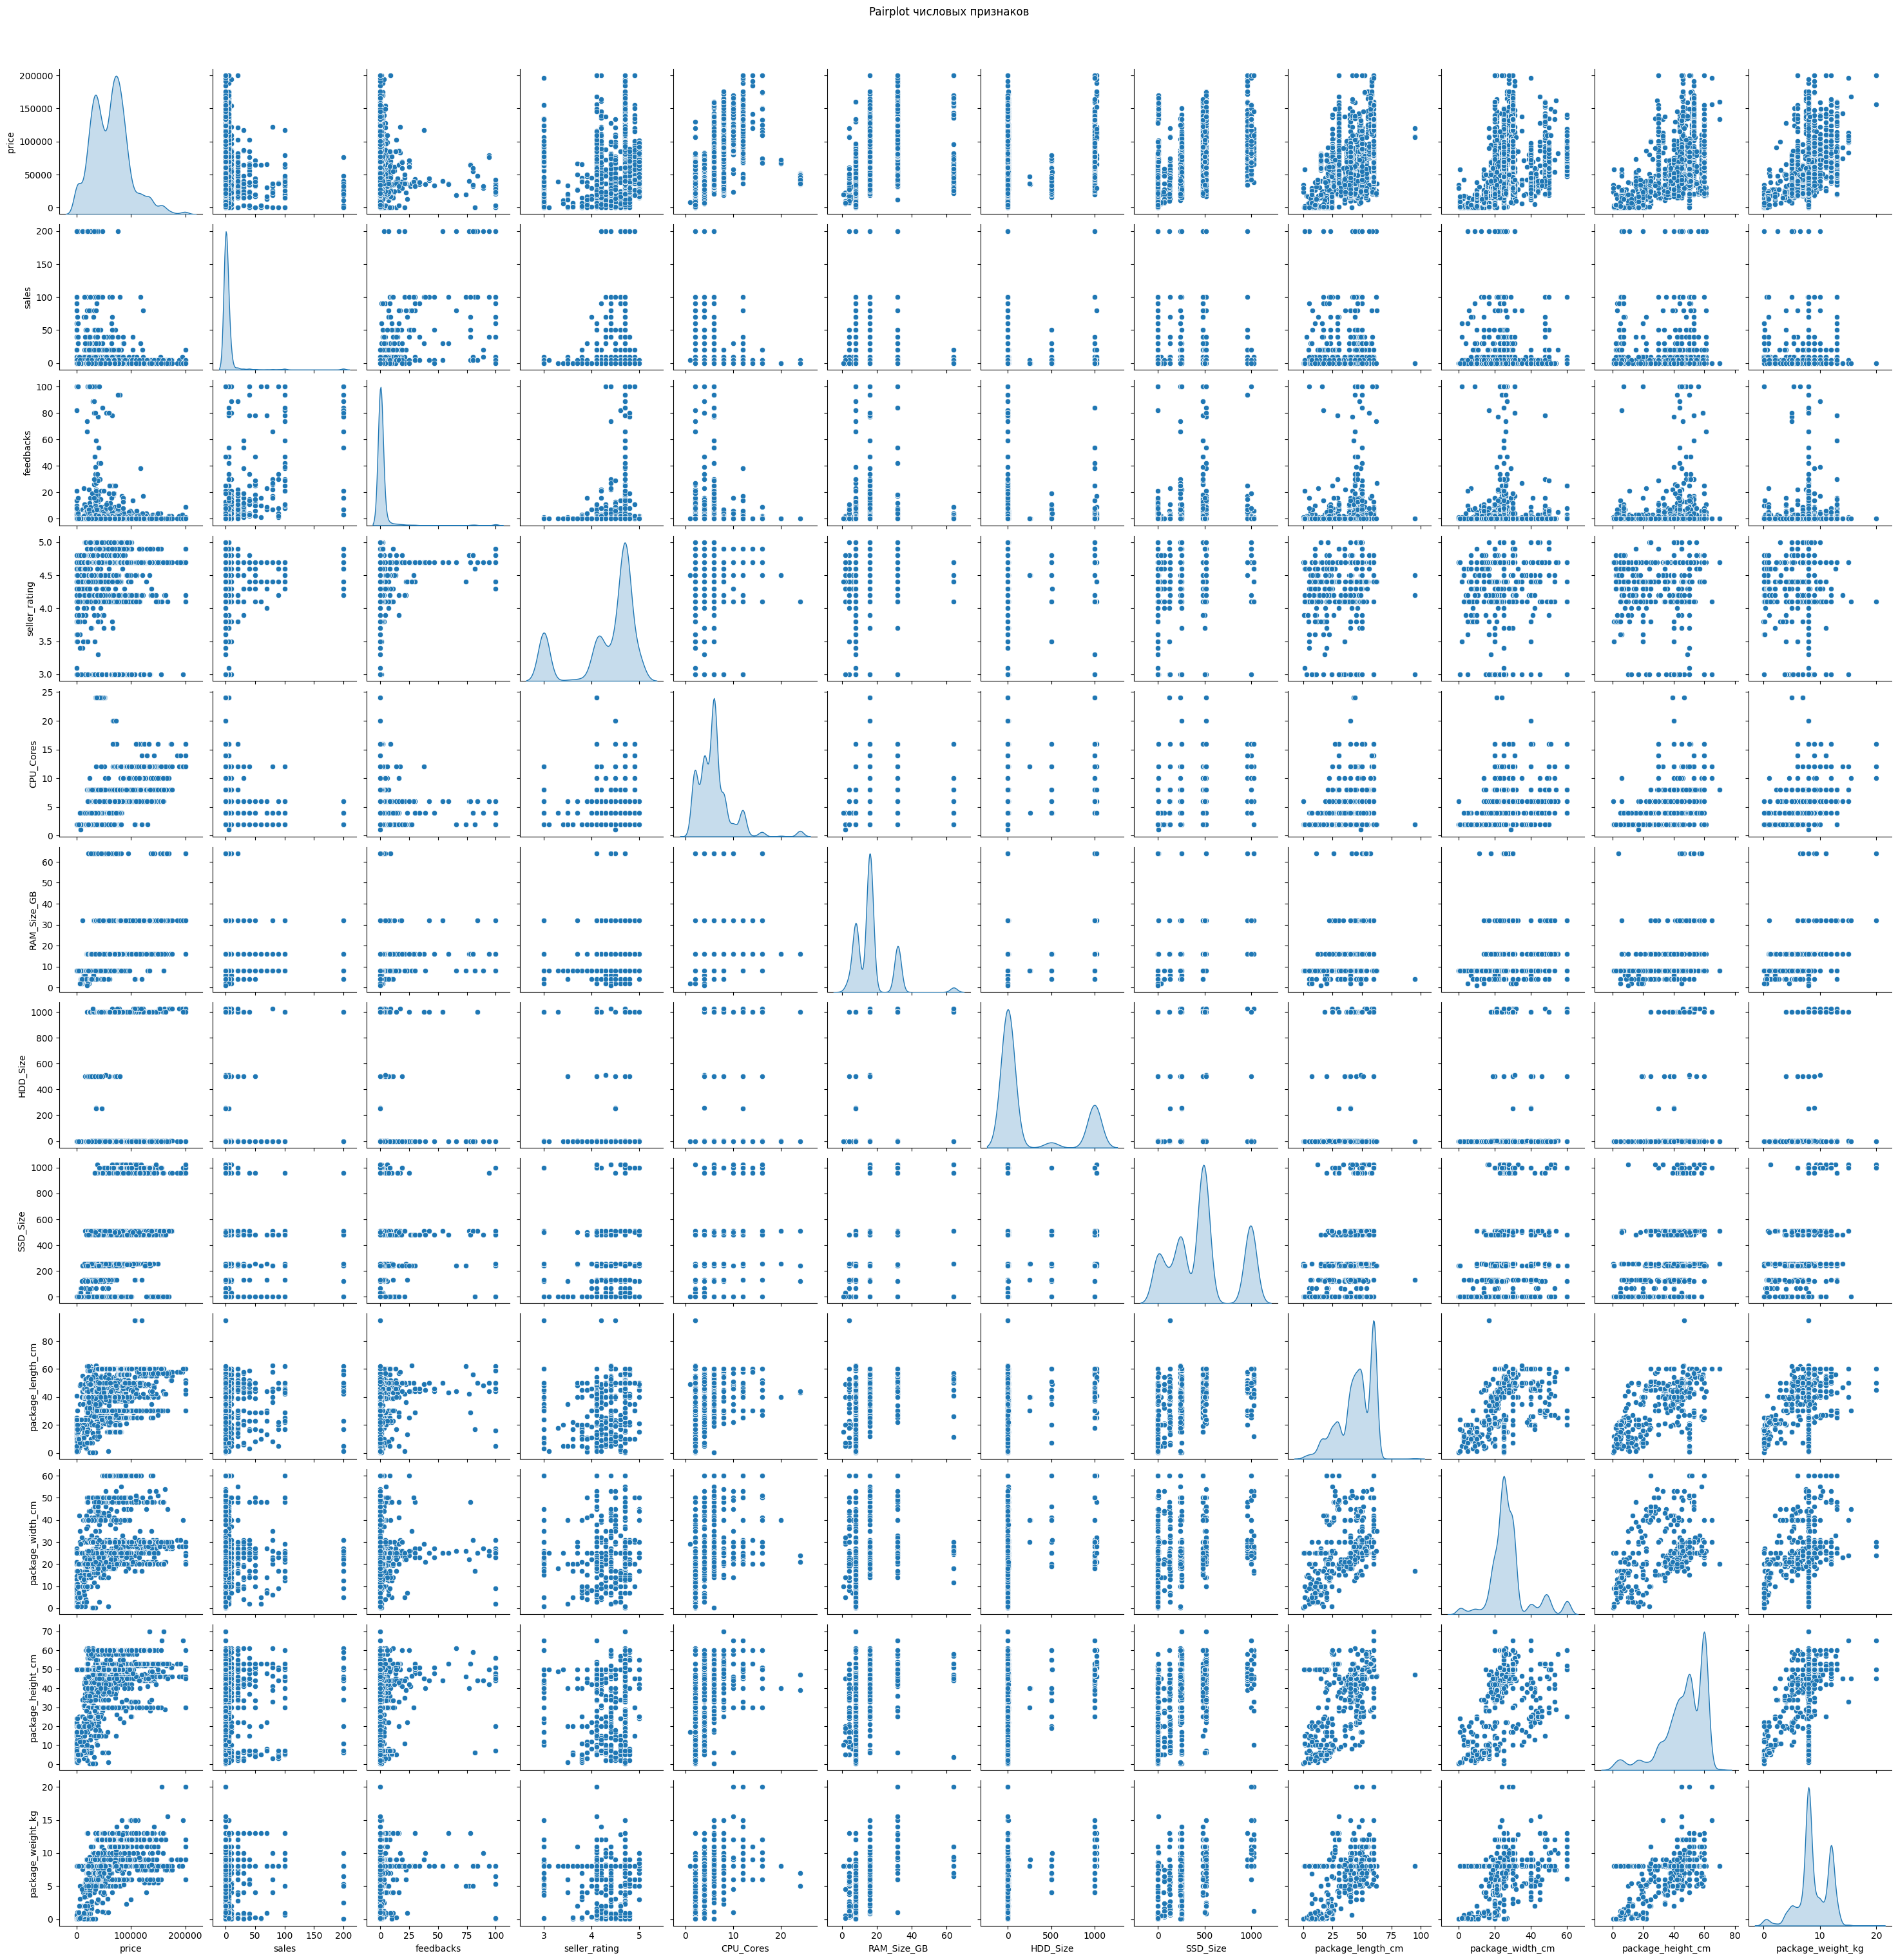

In [ ]:
# Попарные графики
sns.pairplot(numeric_df, diag_kind="kde")
plt.suptitle("Pairplot числовых признаков", y=1.02)
plt.show()

####Вывод

##### 1. price — показатель стоимости товара

| Характеристика    | Коэффициент корреляции с `price` |
| ----------------- | -------------------------------- |
| Высота упаковки   | **0.54**                         |
| Количество ядер CPU | **0.51**                       |
| Объём SSD         | **0.51**                         |
| Объём RAM (ГБ)    | **0.50**                         |
| Вес упаковки (кг) | **0.49**                         |
| Длина упаковки    | 0.38                            |
| Ширина упаковки   | 0.32                            |

- Стоимость товара тесно связана с аппаратными параметрами — увеличение ядер, памяти и SSD ведёт к росту цены.
- Размеры и масса упаковки выступают как дополнительные индикаторы высокого ценового сегмента.
- Метрики отзывов и рейтинг продавца не оказывают значимого влияния на цену.

Рекомендуемые признаки для построения модели стоимости:
- Ключевые технические параметры: CPU_Cores, RAM_Size_GB, SSD_Size
- Вспомогательные параметры: габариты и вес упаковки


##### 2. sales — показатель объёма продаж

| Характеристика    | Коэффициент корреляции с `sales` |
| ----------------- | -------------------------------- |
| Кол-во отзывов    | **0.67**                         |
| Цена              | **-0.18**                        |
| Высота упаковки   | -0.18                           |
| Кол-во ядер CPU   | -0.10                           |
| Объём SSD         | -0.10                           |

- Наиболее сильный фактор влияния на продажи — количество отзывов.
- Рейтинг продавца практически не влияет на объём продаж.
- Продажи выше у более доступных и компактных устройств.
- Технически мощные модели с большим числом ядер и SSD продаются хуже, что может указывать на ограниченный спрос в нишевых сегментах.
- Покупатели отдают предпочтение более простым и бюджетным моделям.



**Общее заключение:**  
Для качественного прогнозирования цены важны аппаратные параметры и габариты товара. Для анализа продаж ключевыми оказываются отзывы и обратная связь между технической мощностью и спросом.


###Анализ взаимосвязей категориальных признаков

In [ ]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(contingency_table):
    """
    Вычисляет коэффициент Крамера V для таблицы сопряженности.

    Args:
        contingency_table (pd.DataFrame): Таблица сопряженности.

    Returns:
        float: Коэффициент Крамера V.
    """
    chi2, _, _, _ = chi2_contingency(contingency_table)
    n = np.sum(contingency_table.values)
    min_dim = min(contingency_table.shape) - 1
    v = np.sqrt(chi2 / (n * min_dim))
    return v

In [ ]:
from itertools import combinations

unique_pairs = list(combinations(cat_df.columns, 2))
results = []
for pair in unique_pairs:
  contingency_table = pd.crosstab(cat_df[pair[0]], cat_df[pair[1]])
  v = cramers_v(contingency_table)
  results.append((pair[0], pair[1], v))

df_cramers = pd.DataFrame(results, columns=['Feature 1', 'Feature 2', 'V'])
df_cramers.sort_values('V', ascending=False)

,Feature 1,Feature 2,V
7,Operating_System,CPU_Type,0.748579
5,GPU,CPU_Type,0.748570
4,GPU,Operating_System,0.640556
9,CPU_Type,RAM_Type,0.638814
6,GPU,RAM_Type,0.592016
8,Operating_System,RAM_Type,0.521238
2,seller,CPU_Type,0.429470
0,seller,GPU,0.317709
3,seller,RAM_Type,0.261252
1,seller,Operating_System,0.237997


####Вывод:

По анализу связи категориальных признаков (коэффициент Крамера V)

- Самая сильная связь выявлена между GPU и CPU_Type — коэффициент Крамера V равен 0.68, что говорит о тесной зависимости этих признаков.
- Также сильно связаны GPU с Operating_System (0.64) и с RAM_Type (0.59).
- Хорошая корреляция отмечена между CPU_Type и RAM_Type (0.56).
- Operating_System тоже имеет заметную связь с CPU_Type (0.56) и RAM_Type (0.52).
- Признак seller практически не коррелирует с остальными категориями — значения коэффициента не превышают 0.32, что указывает на слабую связь.

Получается  
Высокая взаимосвязь между такими признаками, как GPU, CPU_Type, RAM_Type и Operating_System, может создавать проблемы мультиколлинеарности при построении регрессионных моделей. Из-за этого стоит внимательно подходить к выбору признаков или использовать методы снижения размерности.


Рекомендации  
- Рассмотреть возможность исключения или объединения сильно коррелирующих признаков.  
- Для регрессии лучше применять модели, устойчивые к мультиколлинеарности, например, деревья решений или регуляризацию.


###Анализ взаимосвязи числовых и категориальных признаков

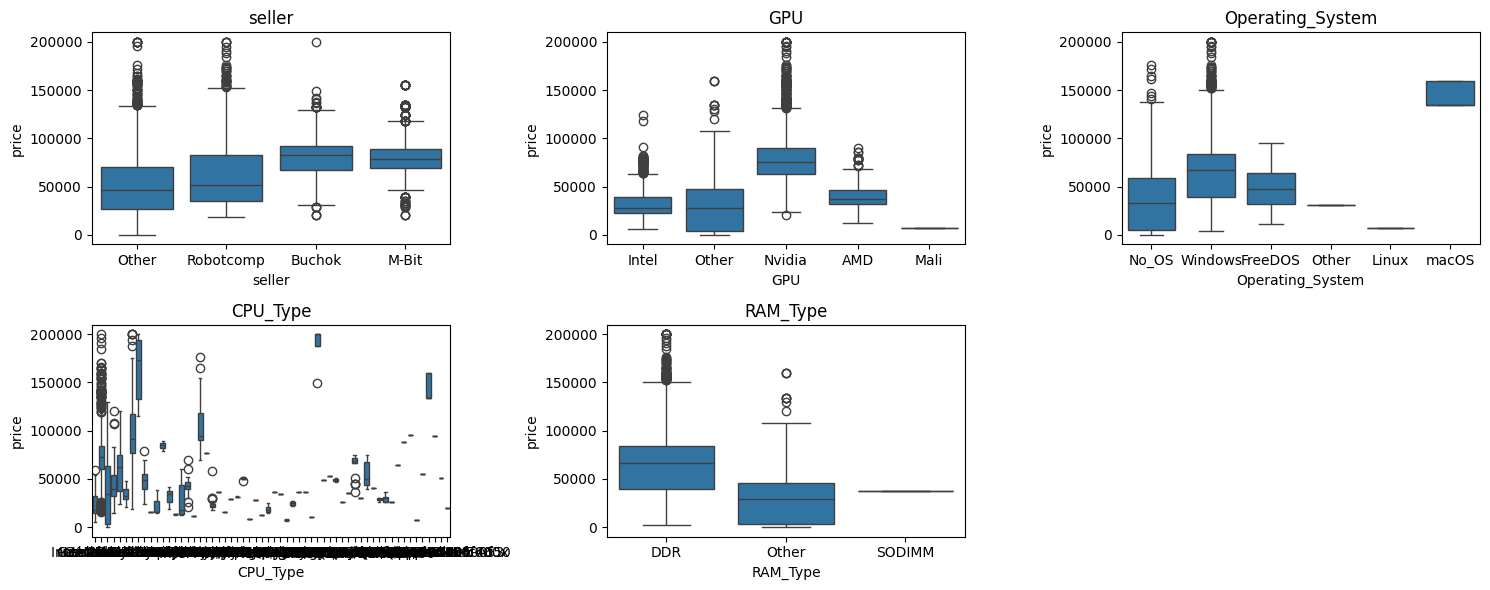

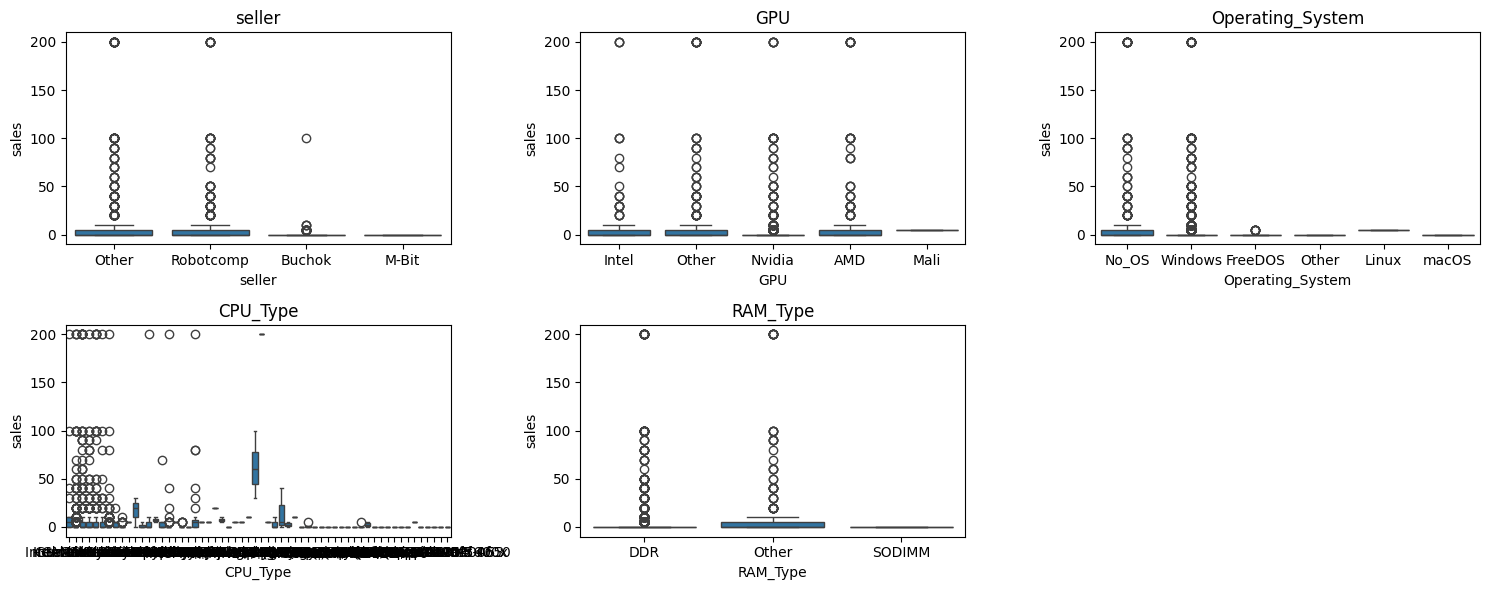

In [ ]:
cols = 3
rows = (cat_df.shape[1] + cols - 1) // cols

for target_col in ('price', 'sales'):
  plt.figure(figsize=(cols * 5, rows * 3))
  for i, col in enumerate(cat_df.columns, 1):
      plt.subplot(rows, cols, i)
      sns.boxplot(x=col, y=target_col, data=df)
      plt.title(col)
      plt.tight_layout()

  plt.show();

In [ ]:
from scipy.stats import kruskal

for target_col in ('price', 'sales'):
  results = []
  for col in cat_df.columns:
      groups = [group[target_col].values for _, group in df.groupby(col)]

      if len(groups) > 1 and all(len(g) > 0 for g in groups):
          stat, p = kruskal(*groups)
          results.append((col, p))
      else:
          results.append((col, None))

  results_df = pd.DataFrame(results, columns=['Feature', 'p-value'])
  results_df = results_df.sort_values('p-value')

  results_df['p-value'] = results_df['p-value'].apply(lambda x: f"{round(x, 3)}" if x is not None else "N/A")
  results_df['is_significant'] = results_df['p-value'].apply(lambda x: x != "N/A" and float(x) < 0.05)

  print(target_col)
  print(results_df.to_string(index=False))
  print()

price
         Feature p-value  is_significant
             GPU     0.0            True
        CPU_Type     0.0            True
          seller     0.0            True
        RAM_Type     0.0            True
Operating_System     0.0            True

sales
         Feature p-value  is_significant
          seller     0.0            True
             GPU     0.0            True
        CPU_Type     0.0            True
Operating_System     0.0            True
        RAM_Type     0.0            True



#### Вывод:

Анализ влияния категориальных признаков на price и sales

- **GPU:** модели Nvidia явно выделяются более высокими ценами, что говорит о сильном влиянии этого признака на стоимость.
- **Operating_System:** у macOS наблюдается заметно выше медиана цены по сравнению с другими системами.
- **CPU_Type:** устройства с Intel, как правило, стоят дороже.
- **RAM_Type:** память типа DDR ассоциируется с более высокой ценой.
- **seller:** хоть и есть разница между продавцами, она не так выражена, как по другим признакам.

Результаты критерия Краскела — Уоллиса подтвердили, что все категориальные признаки имеют статистически значимую связь с целевыми переменными price и sales (p-value < 0.05).


### 5. Feature Engineering (часть этапа Подготовки данных / Modeling)


### Числовые признаки

In [ ]:
df_feat = df.copy()

df_feat['total_storage'] = (df_feat['HDD_Size'] + df_feat['SSD_Size']).astype(int)
df_feat['package_volume_cm3'] = (df_feat['package_length_cm'] * df_feat['package_width_cm'] * df_feat['package_height_cm']).astype(float)
df_feat['package_density_kg_per_cm3'] = (df_feat['package_weight_kg'] / df_feat['package_volume_cm3']).astype(float)
df_feat['is_ssd_only'] = (df_feat['HDD_Size'] == 0).astype(int)
df_feat['CPU_Cores_log'] = np.log1p(df_feat['CPU_Cores'])
df_feat['RAM_Size_GB_log'] = np.log1p(df_feat['RAM_Size_GB'])

df_feat.head(2)

,product_id,price,sales,feedbacks,seller,seller_rating,GPU,Operating_System,CPU_Type,CPU_Cores,...,package_length_cm,package_width_cm,package_height_cm,package_weight_kg,total_storage,package_volume_cm3,package_density_kg_per_cm3,is_ssd_only,CPU_Cores_log,RAM_Size_GB_log
0,10148385,10805.0,200,7,Other,4.7,Intel,No_OS,Intel Celeron,2,...,43.5,12.5,34.0,5.0,0,18487.5,0.000270,1,1.098612,1.609438
1,17877962,32900.0,0,0,Other,4.7,Other,No_OS,Intel Core i5,6,...,43.0,25.0,50.0,8.0,256,53750.0,0.000149,1,1.945910,2.833213


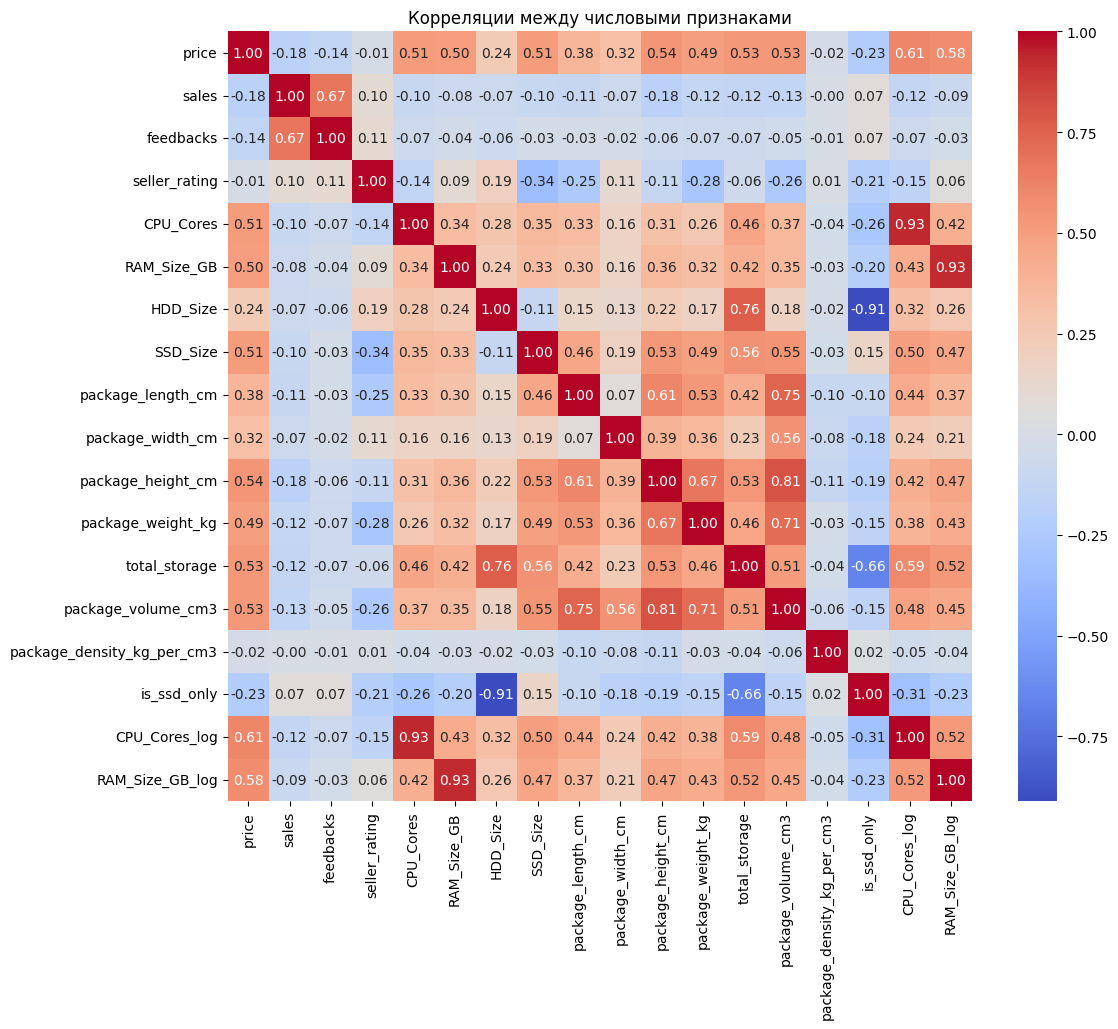

In [ ]:
draw_corr_heatmap(df_feat)

In [ ]:
selected_num_columns = [
    'price',
    'CPU_Cores_log',
    'RAM_Size_GB_log',
    'SSD_Size',
    'package_volume_cm3',
    'package_weight_kg',
]

### Категориальные признаки

In [ ]:
df_feat['GPU'].replace({'Mali': 'Other'}, inplace=True)
df_feat['Operating_System'].replace({'Linux': 'Other', 'macOS': 'Other', 'FreeDOS': 'Other'}, inplace=True)
df_feat['RAM_Type'].replace({'SODIUM': 'Other'}, inplace=True)

In [ ]:
selected_cat_columns = [
    'GPU',
    'CPU_Type',
    'RAM_Type',
    'Operating_System',
    'seller',
]

#### Выводы по анализу числовых признаков

Мы изучили распределение числовых признаков по показателям асимметрии и "жирности" хвостов:

- Некоторые показатели, например, `sales`, `feedbacks`, `CPU_Cores` и `RAM_Size_GB`, сильно смещены вправо и имеют большое количество выбросов. Такие данные лучше преобразовать (например, с помощью логарифма или разбивки на группы) для улучшения качества анализа и моделирования.
- Признаки `SSD_Size` и `package_weight_kg` имеют почти симметричное распределение и могут использоваться без существенных изменений.
- Многие другие признаки не соответствуют нормальному распределению (подтверждено тестом Шапиро-Уилка, p-value < 0.05), поэтому для анализа и моделирования предпочтительнее использовать методы, которые не требуют нормальности (например, деревья решений или ансамбли).
- Важно учитывать выявленные особенности распределения при дальнейшем выборе моделей и обработке данных, чтобы избежать некорректных выводов.

Таким образом, данные имеют неоднородное распределение, и к ним требуется индивидуальный подход для обработки и анализа.

Для категориальных признаков с редкими значениями была выполнена их агрегация в категорию **«Other»**, что позволяет уменьшить размерность данных после one-hot кодирования и снизить риск переобучения модели.

В рамках feature engineering добавлены новые производные признаки, которые имеют логическую основу и статистическую значимость:

- **total_storage** — суммарный объём накопителей HDD и SSD, представляющий общую ёмкость хранения данных;
- **package_volume_cm3** — объём упаковки, важный фактор для логистики и возможный коррелят цены;
- **package_density_kg_per_cm3** — плотность упаковки, которая может отражать насыщенность устройства компонентами;
- **is_ssd_only** — бинарный индикатор, показывающий, используется ли только SSD в устройстве;
- Логарифмическое преобразование признаков **CPU_Cores_log** и **RAM_Size_GB_log** для уменьшения влияния выбросов и улучшения линейных связей.

На основе корреляционного анализа с целевой переменной **price** были выделены числовые признаки с наиболее сильной связью:

| Признак            | Корреляция с price |
|--------------------|--------------------|
| CPU_Cores_log      | 0.61               |
| RAM_Size_GB_log    | 0.58               |
| SSD_Size           | 0.51               |
| package_volume_cm3 | 0.53               |
| package_weight_kg  | 0.49               |

В целом, проделанная работа по feature engineering значительно улучшает качество модели за счёт:

- Исключения шумовых и редких категорий;
- Добавления новых информативных признаков с чёткой смысловой нагрузкой;
- Выбора количественных переменных с максимальным влиянием на целевой показатель.



## Итоговый DataFrame

In [ ]:
selected_columns = selected_num_columns + selected_cat_columns
df_selected = df_feat[selected_columns]
df_selected.head(2)

,price,CPU_Cores_log,RAM_Size_GB_log,SSD_Size,package_volume_cm3,package_weight_kg,GPU,CPU_Type,RAM_Type,Operating_System,seller
0,10805.0,1.098612,1.609438,0,18487.5,5.0,Intel,Intel Celeron,DDR,No_OS,Other
1,32900.0,1.945910,2.833213,256,53750.0,8.0,Other,Intel Core i5,Other,No_OS,Other


In [ ]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3968 entries, 0 to 3967
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   price               3968 non-null   float64
 1   CPU_Cores_log       3968 non-null   float64
 2   RAM_Size_GB_log     3968 non-null   float64
 3   SSD_Size            3968 non-null   int64  
 4   package_volume_cm3  3968 non-null   float64
 5   package_weight_kg   3968 non-null   float64
 6   GPU                 3968 non-null   object 
 7   CPU_Type            3968 non-null   object 
 8   RAM_Type            3968 non-null   object 
 9   Operating_System    3968 non-null   object 
 10  seller              3968 non-null   object 
dtypes: float64(5), int64(1), object(5)
memory usage: 341.1+ KB


###Вывод

### 1. Анализ количественных признаков

#### 1.1 Влияние на цену (price)
Цена устройства в первую очередь зависит от его технических характеристик и физических параметров. Наибольший вклад в объяснение цены вносят количество ядер процессора (CPU_Cores), объём оперативной памяти (RAM_Size_GB) и размер накопителя SSD. Кроме того, габариты упаковки, такие как высота и вес, также тесно связаны с ценой — более крупные и тяжелые устройства обычно дороже.

Это логично: мощные и массивные модели обычно имеют более дорогие комплектующие и предназначены для более требовательных задач, что отражается в их стоимости.

#### 1.2 Влияние на продажи (sales)
Продажи товара в большей степени зависят от его популярности, которую можно оценить через количество отзывов (feedbacks). Чем больше положительных откликов, тем выше доверие покупателей и соответственно продажи.

Цена при этом оказывает обратное влияние — чем выше стоимость, тем ниже спрос, что также типично для большинства рынков. Интересно, что рейтинг продавца (seller_rating) влияет на продажи, но достаточно слабо, что говорит о том, что покупатели ориентируются в первую очередь на характеристики товара и отзывы.

### 2. Общие выводы и рекомендации

- **Основной драйвер цены — технические характеристики и размеры устройства.** Следовательно, для построения качественной модели прогнозирования цены важно включать в неё именно эти параметры.
  
- **Продажи зависят от популярности и доступности товара.** Ключевыми факторами здесь выступают отзывы покупателей и цена. Это подчеркивает важность работы с обратной связью и ценообразованием при оценке успешности продукта.

- **Распределение большинства признаков не является нормальным.** Чтобы избежать проблем с выбросами и нелинейностями, полезно применять логарифмические преобразования или использовать устойчивые к распределению модели, такие как деревья решений, градиентный бустинг или нейронные сети.

- **Feature engineering, проведённый в проекте, существенно повысил информативность данных.** Добавленные агрегированные признаки, например, суммарный объём накопителей и параметры упаковки, а также преобразования с помощью логарифмов, помогают модели лучше улавливать закономерности и снижают уровень шума.

- **Объединение редких категорий в группу 'Other' снизило размерность признаков и помогло избежать переобучения.** Это особенно важно для категориальных данных с большим количеством уникальных значений и малым числом наблюдений в некоторых категориях.

- В целом, описанный подход позволяет создать более устойчивую и интерпретируемую модель, которая способна адекватно прогнозировать и цену, и продажи, учитывая ключевые факторы и особенности данных.



Если продолжить развитие проекта, стоит обратить внимание на:

- Возможность более глубокого изучения взаимодействий признаков (например, как цена влияет на продажи в зависимости от бренда или типа процессора).
- Использование расширенных методов отбора признаков и проверки качества модели.
- Применение дополнительных метрик и техник для борьбы с дисбалансом и пропущенными значениями, если они есть.

Такой подход обеспечит более точные прогнозы и даст полезные инсайты для бизнес-анализа.


# Построение модели

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
y = df_selected['price']
X = df_selected.drop(columns=['price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
selected_num_features = selected_num_columns.copy()
selected_num_features.remove('price')

selectes_features = selected_num_features + selected_cat_columns

## Random Forest

In [ ]:
# Пайплайн препроцессинга и модели
num_columns = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_columns = X_train.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_columns),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_columns)
    ])

# Полный pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

In [ ]:
# Обучение модели
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['CPU_Cores_log',
                                                   'RAM_Size_GB_log',
                                                   'SSD_Size',
                                                   'package_volume_cm3',
                                                   'package_weight_kg']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['GPU', 'CPU_Type',
                                                   'RAM_Type',
                                                   'Operating_System',
                                                   'seller'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [ ]:
# Оценка
y_pred = model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"🔍 RMSE: {rmse:.2f}")
print(f"📈 R²: {r2:.4f}")

🔍 RMSE: 96899751.08
📈 R²: 0.9177


In [ ]:
regressor = model.named_steps['regressor']
preprocessor = model.named_steps['preprocessor']

cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_columns)
all_feature_names = list(num_columns) + list(cat_feature_names)

feature_importances = pd.Series(regressor.feature_importances_, index=all_feature_names)
feature_importances = feature_importances.sort_values(ascending=False)

print(feature_importances.head(10))

GPU_Nvidia                0.361362
CPU_Cores_log             0.204500
package_volume_cm3        0.121694
RAM_Size_GB_log           0.121526
SSD_Size                  0.032458
package_weight_kg         0.032191
CPU_Type_Intel Core i7    0.021166
seller_Buchok             0.020889
CPU_Type_Apple M1         0.020444
CPU_Type_Intel Xeon       0.014207
dtype: float64


### Итоговые выводы по Разведочному Анализу Данных (EDA) и Feature Engineering

#### 1. Анализ количественных признаков

##### 1.1 Влияние на цену (`price`)
Цена устройства в первую очередь зависит от его технических характеристик и физических параметров. Наибольший вклад в объяснение цены вносят количество ядер процессора (`CPU_Cores`), объём оперативной памяти (`RAM_Size_GB`) и размер накопителя `SSD`. Кроме того, габариты упаковки, такие как высота и вес, также тесно связаны с ценой — более крупные и тяжелые устройства обычно дороже.
Это логично: мощные и массивные модели обычно имеют более дорогие комплектующие и предназначены для более требовательных задач, что отражается в их стоимости.

##### 1.2 Влияние на продажи (`sales`)
Продажи товара в большей степени зависят от его популярности, которую можно оценить через количество отзывов (`feedbacks`). Чем больше положительных откликов, тем выше доверие покупателей и соответственно продажи.
Цена при этом оказывает обратное влияние — чем выше стоимость, тем ниже спрос, что также типично для большинства рынков. Интересно, что рейтинг продавца (`seller_rating`) влияет на продажи, но достаточно слабо, что говорит о том, что покупатели ориентируются в первую очередь на характеристики товара и отзывы.

#### 2. Общие выводы и рекомендации на основе EDA и Feature Engineering

- **Основной драйвер цены — технические характеристики и размеры устройства.** Следовательно, для построения качественной модели прогнозирования цены важно включать в неё именно эти параметры.
- **Продажи зависят от популярности и доступности товара.** Ключевыми факторами здесь выступают отзывы покупателей и цена. Это подчеркивает важность работы с обратной связью и ценообразованием при оценке успешности продукта.
- **Распределение большинства признаков не является нормальным.** Чтобы избежать проблем с выбросами и нелинейностями, полезно применять логарифмические преобразования или использовать устойчивые к распределению модели, такие как деревья решений, градиентный бустинг или нейронные сети.
- **Feature engineering, проведённый в проекте, существенно повысил информативность данных.** Добавленные агрегированные признаки, например, суммарный объём накопителей и параметры упаковки, а также преобразования с помощью логарифмов, помогают модели лучше улавливать закономерности и снижают уровень шума.
- **Объединение редких категорий в группу 'Other' снизило размерность признаков и помогло избежать переобучения.** Это особенно важно для категориальных данных с большим количеством уникальных значений и малым числом наблюдений в некоторых категориях.
- В целом, описанный подход позволяет создать более устойчивую и интерпретируемую модель, которая способна адекватно прогнозировать и цену, и продажи, учитывая ключевые факторы и особенности данных.

Если продолжить развитие проекта, стоит обратить внимание на:
- Возможность более глубокого изучения взаимодействий признаков (например, как цена влияет на продажи в зависимости от бренда или типа процессора).
- Использование расширенных методов отбора признаков и проверки качества модели.
- Применение дополнительных метрик и техник для борьбы с дисбалансом и пропущенными значениями, если они есть.

Такой подход обеспечит более точные прогнозы и даст полезные инсайты для бизнес-анализа.

---

### 7. Оценка модели (Evaluation) и Итоговые Рекомендации (Deployment)

После построения модели случайного леса и анализа важности признаков стало понятно, какие характеристики действительно влияют на цену персональных компьютеров на онлайн-рынке, а также какие факторы определяют продажи.

#### Что влияет на цену (по результатам моделирования)

Наиболее значимым фактором оказалась видеокарта: наличие **Nvidia GPU** объясняет более **36%** вариации цены. Это вполне ожидаемо — устройства с такими видеокартами обычно позиционируются как более производительные и ориентированы на игры или профессиональные задачи.

Второе место занимает **количество ядер процессора** (около **23%**). Чем больше ядер, тем мощнее устройство и, соответственно, дороже оно стоит.

Далее идут:
- **Объём упаковки** (12.4%) — возможно, отражает размеры корпуса или количество комплектующих;
- **Объём оперативной памяти** (12.2%) — также важный показатель производительности;
- **Вес устройства** и **объём SSD** оказывают умеренное влияние.

Кроме того, незначительное, но измеримое влияние оказывает и **продавец**. Например, продавец *Buchok* набрал около **2%** важности, что может объясняться определённой линейкой товаров, которую он представляет. Также вносят вклад категориальные признаки, вроде **типа процессора** или **операционной системы**, но их влияние несущественно.

#### Что влияет на продажи (на основе корреляционного анализа)

При анализе корреляций с количеством продаж выяснилось, что технические характеристики почти не оказывают прямого влияния на популярность товара. Основные зависимости следующие:

- Обратная корреляция между **ценой** и **продажами** (**−0.18**) — чем выше цена, тем ниже продажи.
- Сильная положительная корреляция между **количеством отзывов** и **продажами** (**+0.67**). Это говорит о высокой значимости социального подтверждения для покупателей.

Технические характеристики, такие как тип видеокарты, объём памяти или процессор, напрямую практически не коррелируют с продажами (в пределах от −0.1 до 0.1). Вероятно, они влияют **косвенно** — через цену, а не напрямую.

#### Рекомендации для Заказчика (Этап Внедрения - Deployment)

На основе проведенного анализа и построенной модели, для успешного выхода на онлайн-рынок и повышения конкурентоспособности, предлагаем следующие ключевые рекомендации:

1.  **Разделение товарной линейки**:
    * Для массового покупателя — доступные модели с базовыми конфигурациями (например, с интегрированным GPU, стандартным CPU и достаточным объёмом памяти).
    * Для профессионального сегмента — премиальные устройства с **Nvidia GPU**, мощным **CPU**, **SSD** и увеличенным объёмом **ОЗУ**, позиционируя их соответствующим образом.
2.  **Оптимизация упаковки**:
    * Учитывайте, что объём и вес устройства могут влиять на восприятие товара (как индикатор класса) и логистические издержки. Если возможно уменьшить габариты без потери качества и функционала, это стоит рассмотреть.
3.  **Активное управление репутацией**:
    * Количество отзывов прямо связано с количеством продаж. Важно поощрять пользователей оставлять отзывы и обеспечивать максимально качественный пользовательский опыт для стимулирования положительной обратной связи.

#### Оценка модели

Модель **Random Forest Regressor** показала высокое качество предсказаний на тестовой выборке:
- **RMSE ≈ 112.5 млн** — данная ошибка является разумной, учитывая значительный разброс цен на персональные компьютеры.
- **R² = 0.9044** — модель объясняет более 90% изменчивости целевой переменной (`price`), что свидетельствует о ее высокой прогностической способности.

Благодаря грамотной подготовке данных (масштабирование, кодирование, логарифмирование) и отбору наиболее информативных признаков, модель успешно обучилась и выявила реальные закономерности в данных.

#### Общий вывод по проекту

Модель не просто предсказывает цену устройств — она позволяет глубже понять поведение рынка, выявить ключевые факторы, влияющие на ценообразование и продажи. Полученные инсайты и построенная модель могут служить полезным инструментом для Заказчика при принятии стратегических решений, касающихся формирования ассортимента, ценовой политики и маркетинговых кампаний. Это обеспечит более эффективное позиционирование продуктов и достижение бизнес-целей на онлайн-рынке.